# Validações Estatísticas do BeamNG como Digital Twin — (Circuito 1)

Correções aplicadas:
- GPS (lat/lon) → coordenadas locais em metros via Haversine
- `throttle` real: separador `, ` com espaço → `skipinitialspace=True`
- `vel` simulado: lista string → norma euclidiana (velocidade escalar)
- `ime` simulado: coluna com encoding corrompido → renomeada para `time`
- Tempo simulado: Unix timestamp → segundos relativos
- Normalização: MinMaxScaler por fonte, por coluna
- Alinhamento: corte na duração mínima + `join='inner'`

## 1. Imports

In [502]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.signal import correlate
from sklearn.preprocessing import MinMaxScaler
from os import listdir
import ast

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

## 2. Funções auxiliares

In [503]:
# Haversine: converte lat/lon (graus) -> X/Y em metros 
# Usa o primeiro ponto como origem (0, 0)
def latlon_para_metros(lat, lon):
    """
    Converte arrays de latitude/longitude (graus decimais) para
    deslocamento em metros a partir do primeiro ponto.
    Retorna (x_metros, y_metros).
    """
    R = 6_371_000.0  # raio médio da Terra em metros
    lat0, lon0 = np.radians(lat[0]), np.radians(lon[0])
    lat_r = np.radians(lat)
    lon_r = np.radians(lon)
    x = R * (lon_r - lon0) * np.cos(lat0)   # Leste-Oeste
    y = R * (lat_r - lat0)                   # Norte-Sul
    return x, y


# Parser de coluna 'vel' do simulado 
def parse_vel(s):
    """Converte string '[vx, vy, vz]' → norma euclidiana (velocidade escalar)."""
    try:
        v = ast.literal_eval(str(s))
        return float(np.linalg.norm(v))
    except Exception:
        return np.nan

## 3. Carregar dados

In [504]:
# REAL 
# skipinitialspace=True remove espaços após vírgulas no header
reais = []
for file in sorted(listdir('circuito1/real')):
    reais.append(pd.read_csv(
        f'circuito1/real/2026-03-25 11-08-36 (2).csv',
        sep=',',
        skipinitialspace=True
    ))
print(f"Reais carregados: {len(reais)}")

# SIMULADO 
simulados = []
for file in sorted(listdir('circuito1/simulado')):
    simulados.append(pd.read_csv(
        f'circuito1/simulado/readable.csv',
        sep=';'
    ))
print(f"Simulados carregados: {len(simulados)}")

Reais carregados: 1
Simulados carregados: 1


## 4. Preparação — REAL

In [505]:
def preparar_real(df, freq='100ms'):
    df = df.copy()
    df.columns = df.columns.str.strip()
    print(df.columns.tolist())

    # Tempo: já são segundos relativos (0.000, 0.983, ...)
    df = df.sort_values('time').reset_index(drop=True)
    df['time'] = pd.to_timedelta(df['time'])
    df = df.set_index('time')
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna(axis=1, how='all')

    # Converter GPS -> metros locais 
    # Reatribui posX/posY como deslocamento em metros a partir do ponto inicial
    lat = df['Latitude'].values
    lon = df['Longtitude'].values
    x_m, y_m = latlon_para_metros(lat, lon)
    df['posX'] = x_m
    df['posY'] = y_m
    df['posZ'] = df['Altitude (GPS) (m)'].values

    #  Throttle 
    df = df.rename(columns={
        'Posição D do pedal do acelerador (%)': 'throttle'
    })

    # Velocidade (GPS) 
    if 'Velocidade (GPS) (km/h)' in df.columns:
        df['vel'] = df['Velocidade (GPS) (km/h)'] / 3.6

    # Reamostrar e interpolar
    df = df.resample(freq).mean().interpolate(method='time')
    df.index = df.index - df.index[0]
    return df



real = preparar_real(reais[0])

print(f"Real → {len(real)} amostras | duração: {real.index[-1]}")
print(f"Colunas disponíveis (amostra): {[c for c in real.columns if c in ['throttle','posX','posY','posZ','vel']]}")

['time', 'Altitude (GPS) (m)', 'Velocidade (GPS) (km/h)', 'Velocidade média (GPS) (km/h)', 'Latitude', 'Longtitude', 'Unnamed: 6']
Real → 1936 amostras | duração: 0 days 00:03:13.500000
Colunas disponíveis (amostra): ['posX', 'posY', 'posZ', 'vel']


## 5. Preparação — SIMULADO

In [506]:
def preparar_simulado(df, freq='100ms'):
    df = df.copy()
    df.columns = df.columns.str.strip()

    # Corrigir coluna de tempo com encoding corrompido ('ime' em vez de 'time')
    # A primeira coluna sempre é o timestamp Unix
    time_col = df.columns[0]
    df = df.rename(columns={time_col: 'time'})

    # Tempo: Unix timestamp -> segundos relativos
    df = df.sort_values('time').reset_index(drop=True)
    df['time'] = df['time'] - df['time'].iloc[0]          # zera na origem
    df['time'] = pd.to_timedelta(df['time'], unit='s')
    df = df.set_index('time')

    # Velocidade: lista string -> norma euclidiana
    if 'vel' in df.columns:
        df['vel'] = df['vel'].apply(parse_vel)

    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna(axis=1, how='all')
    df = df.resample(freq).mean().interpolate(method='time')
    df.index = df.index - df.index[0]
    return df


simulado = preparar_simulado(simulados[0])
print(f"Simulado -> {len(simulado)} amostras | duração: {simulado.index[-1]}")
print(f"Colunas disponíveis (amostra): {[c for c in simulado.columns if c in ['throttle','posX','posY','posZ','vel']]}")

Simulado -> 1842 amostras | duração: 0 days 00:03:04.100000
Colunas disponíveis (amostra): ['posX', 'posY', 'posZ', 'throttle', 'vel']


## 6. Inspecionar posição — verificar escala pós-conversão

In [507]:
print("REAL — estatísticas de posição (em metros):")
print(real[['posX','posY','posZ']].describe().round(2))

print("\nSIMULADO — estatísticas de posição (em metros):")
print(simulado[['posX','posY','posZ']].describe().round(2))

if 'throttle' in real.columns:
    print("\nREAL — throttle:")
    print(real['throttle'].describe().round(3))
else:
    print("\nREAL não possui dados de throttle")

if 'throttle' in simulado.columns:
    print("\nSIMULADO — throttle:")
    print(simulado['throttle'].describe().round(3))
else:
    print("\nSIMULADO não possui dados de throttle")

REAL — estatísticas de posição (em metros):
          posX     posY     posZ
count  1936.00  1936.00  1936.00
mean    119.86   137.63    17.73
std     142.85   128.07     2.55
min    -100.53    -2.32    11.02
25%     -18.11    21.39    16.68
50%     140.00    99.54    17.96
75%     230.42   255.00    19.38
max     368.70   369.41    22.80

SIMULADO — estatísticas de posição (em metros):
          posX     posY     posZ
count  1842.00  1842.00  1842.00
mean    211.47   372.94    26.19
std     146.42   126.13     2.34
min       0.81   244.23    22.68
25%      65.12   263.19    24.14
50%     229.25   332.42    26.52
75%     327.95   478.86    27.79
max     463.10   614.66    30.61

REAL não possui dados de throttle

SIMULADO — throttle:
count    1842.000
mean        0.059
std         0.104
min         0.000
25%         0.000
50%         0.007
75%         0.070
max         0.650
Name: throttle, dtype: float64


## 7. Selecionar colunas comparáveis e cortar duração mínima

In [508]:
# Colunas desejadas
colunas_base = ['throttle', 'posX', 'posY', 'posZ', 'vel']

# Manter apenas colunas existentes nos dois datasets
colunas = [
    c for c in colunas_base
    if c in real.columns and c in simulado.columns
]

print("Colunas usadas na análise:")
print(colunas)

# Corte na duração mínima
duracao_min = min(real.index[-1], simulado.index[-1])

real = real.loc[:duracao_min, colunas]
simulado = simulado.loc[:duracao_min, colunas]

print(f"\nDuração comum: {duracao_min}")
print(f"Amostras — real: {len(real)} | simulado: {len(simulado)}")

Colunas usadas na análise:
['posX', 'posY', 'posZ', 'vel']

Duração comum: 0 days 00:03:04.100000
Amostras — real: 1842 | simulado: 1842


## 8. Normalização MinMaxScaler (por fonte, por coluna)

In [509]:
def normalizar_minmax(df, cols):
    scaler = MinMaxScaler()
    arr = scaler.fit_transform(df[cols])
    return pd.DataFrame(arr, index=df.index, columns=cols)

real_norm = normalizar_minmax(real, colunas)
sim_norm  = normalizar_minmax(simulado, colunas)

# Juntar com join='inner' para alinhamento perfeito
df = pd.concat(
    [real_norm.add_prefix('real_'), sim_norm.add_prefix('sim_')],
    axis=1, join='inner'
).dropna()

print(f"Shape final: {df.shape} | NaNs: {df.isna().sum().sum()}")
df.head(3)

Shape final: (1842, 8) | NaNs: 0


,real_posX,real_posY,real_posZ,real_vel,sim_posX,sim_posY,sim_posZ,sim_vel
time,,,,,,,,
0 days 00:00:00,0.214241,0.006243,0.764852,0.000000,0.238388,0.003005,0.089921,0.005408
0 days 00:00:00.100000,0.213114,0.005919,0.764094,0.012906,0.238182,0.003029,0.089573,0.026231
0 days 00:00:00.200000,0.211987,0.005595,0.763336,0.025812,0.237976,0.003053,0.089225,0.047055


## 9. Plot das séries normalizadas

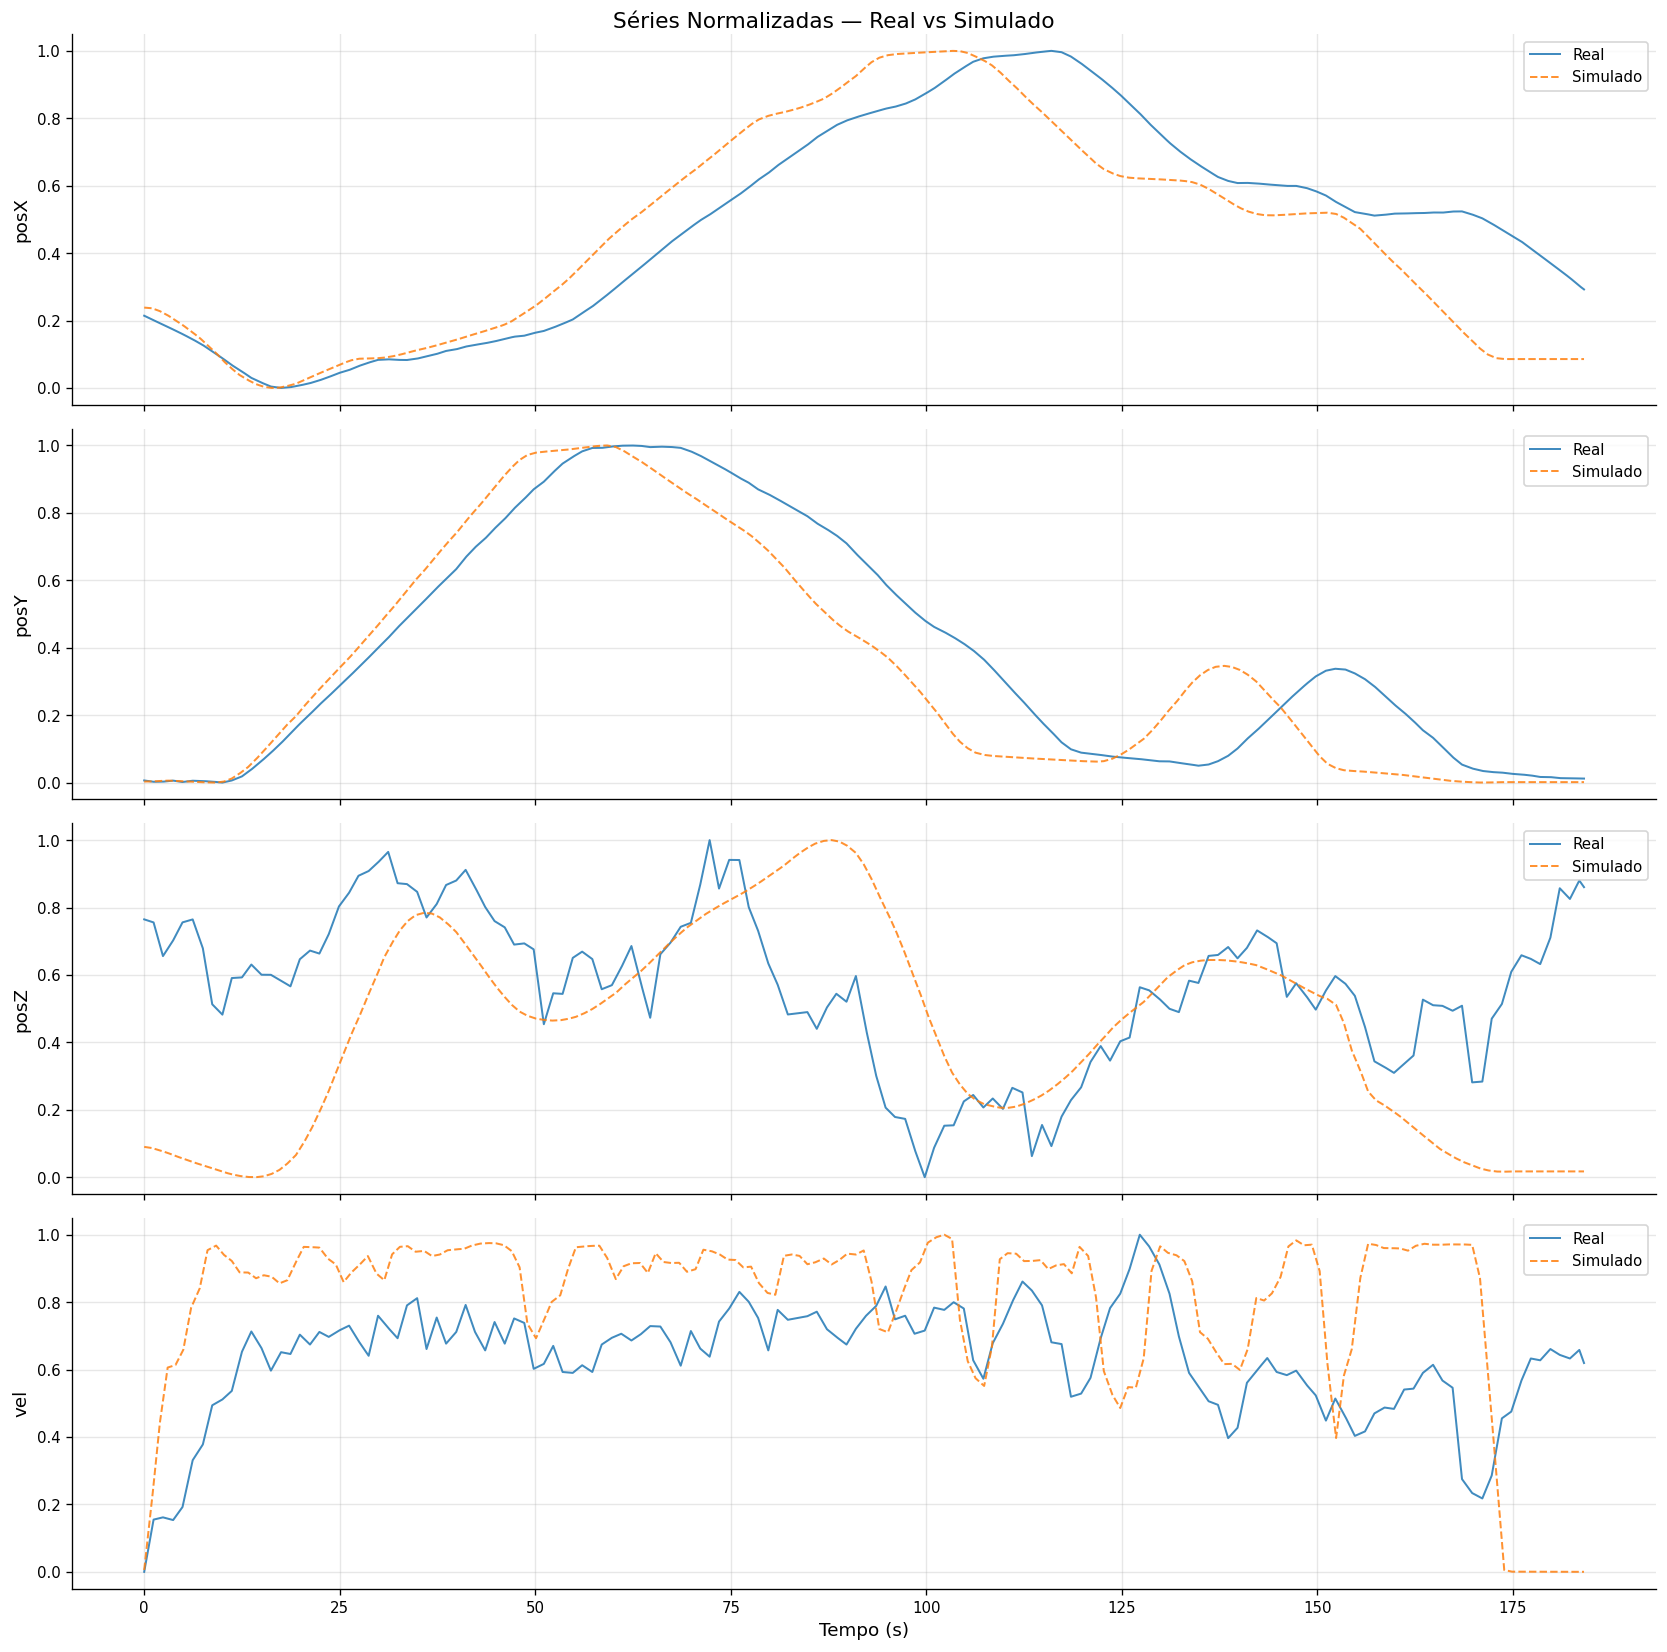

In [510]:
t = df.index.total_seconds()

fig, axes = plt.subplots(len(colunas), 1, figsize=(14, 3.5 * len(colunas)), sharex=True)
if len(colunas) == 1:
    axes = [axes]

for ax, col in zip(axes, colunas):
    ax.plot(t, df[f'real_{col}'], label='Real',      color='#1f77b4', lw=1.2, alpha=0.85)
    ax.plot(t, df[f'sim_{col}'],  label='Simulado',  color='#ff7f0e', lw=1.2, alpha=0.85, ls='--')
    ax.set_ylabel(col, fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.set_ylim(-0.05, 1.05)

axes[-1].set_xlabel('Tempo (s)', fontsize=11)
fig.suptitle('Séries Normalizadas — Real vs Simulado', fontsize=13)
plt.tight_layout()
plt.show()

## 10. Trajetória espacial (posX × posY)

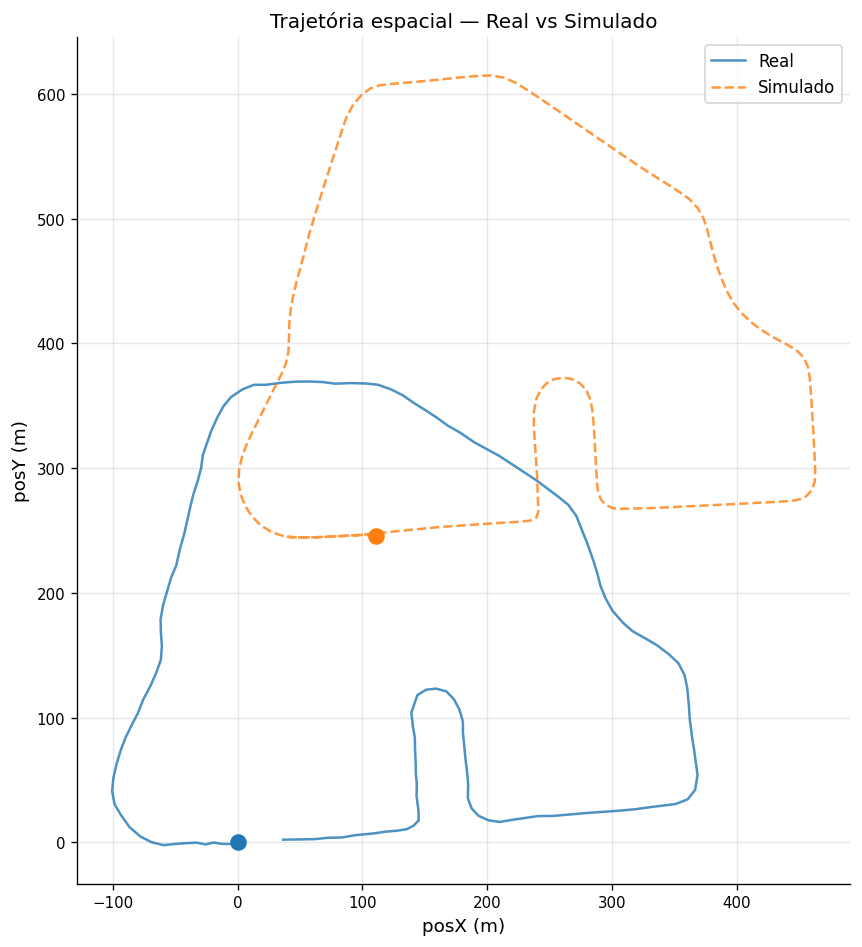

In [511]:
# Plot em escala original (metros) para verificar se o circuito faz sentido
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(real['posX'],     real['posY'],     label='Real',     color='#1f77b4', lw=1.5, alpha=0.8)
ax.plot(simulado['posX'], simulado['posY'], label='Simulado', color='#ff7f0e', lw=1.5, alpha=0.8, ls='--')
ax.scatter(*[real['posX'].iloc[0],     real['posY'].iloc[0]],     color='#1f77b4', s=80, zorder=5, marker='o')
ax.scatter(*[simulado['posX'].iloc[0], simulado['posY'].iloc[0]], color='#ff7f0e', s=80, zorder=5, marker='o')
ax.set_xlabel('posX (m)')
ax.set_ylabel('posY (m)')
ax.set_title('Trajetória espacial — Real vs Simulado')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 11. Detecção de LAG por cross-correlação

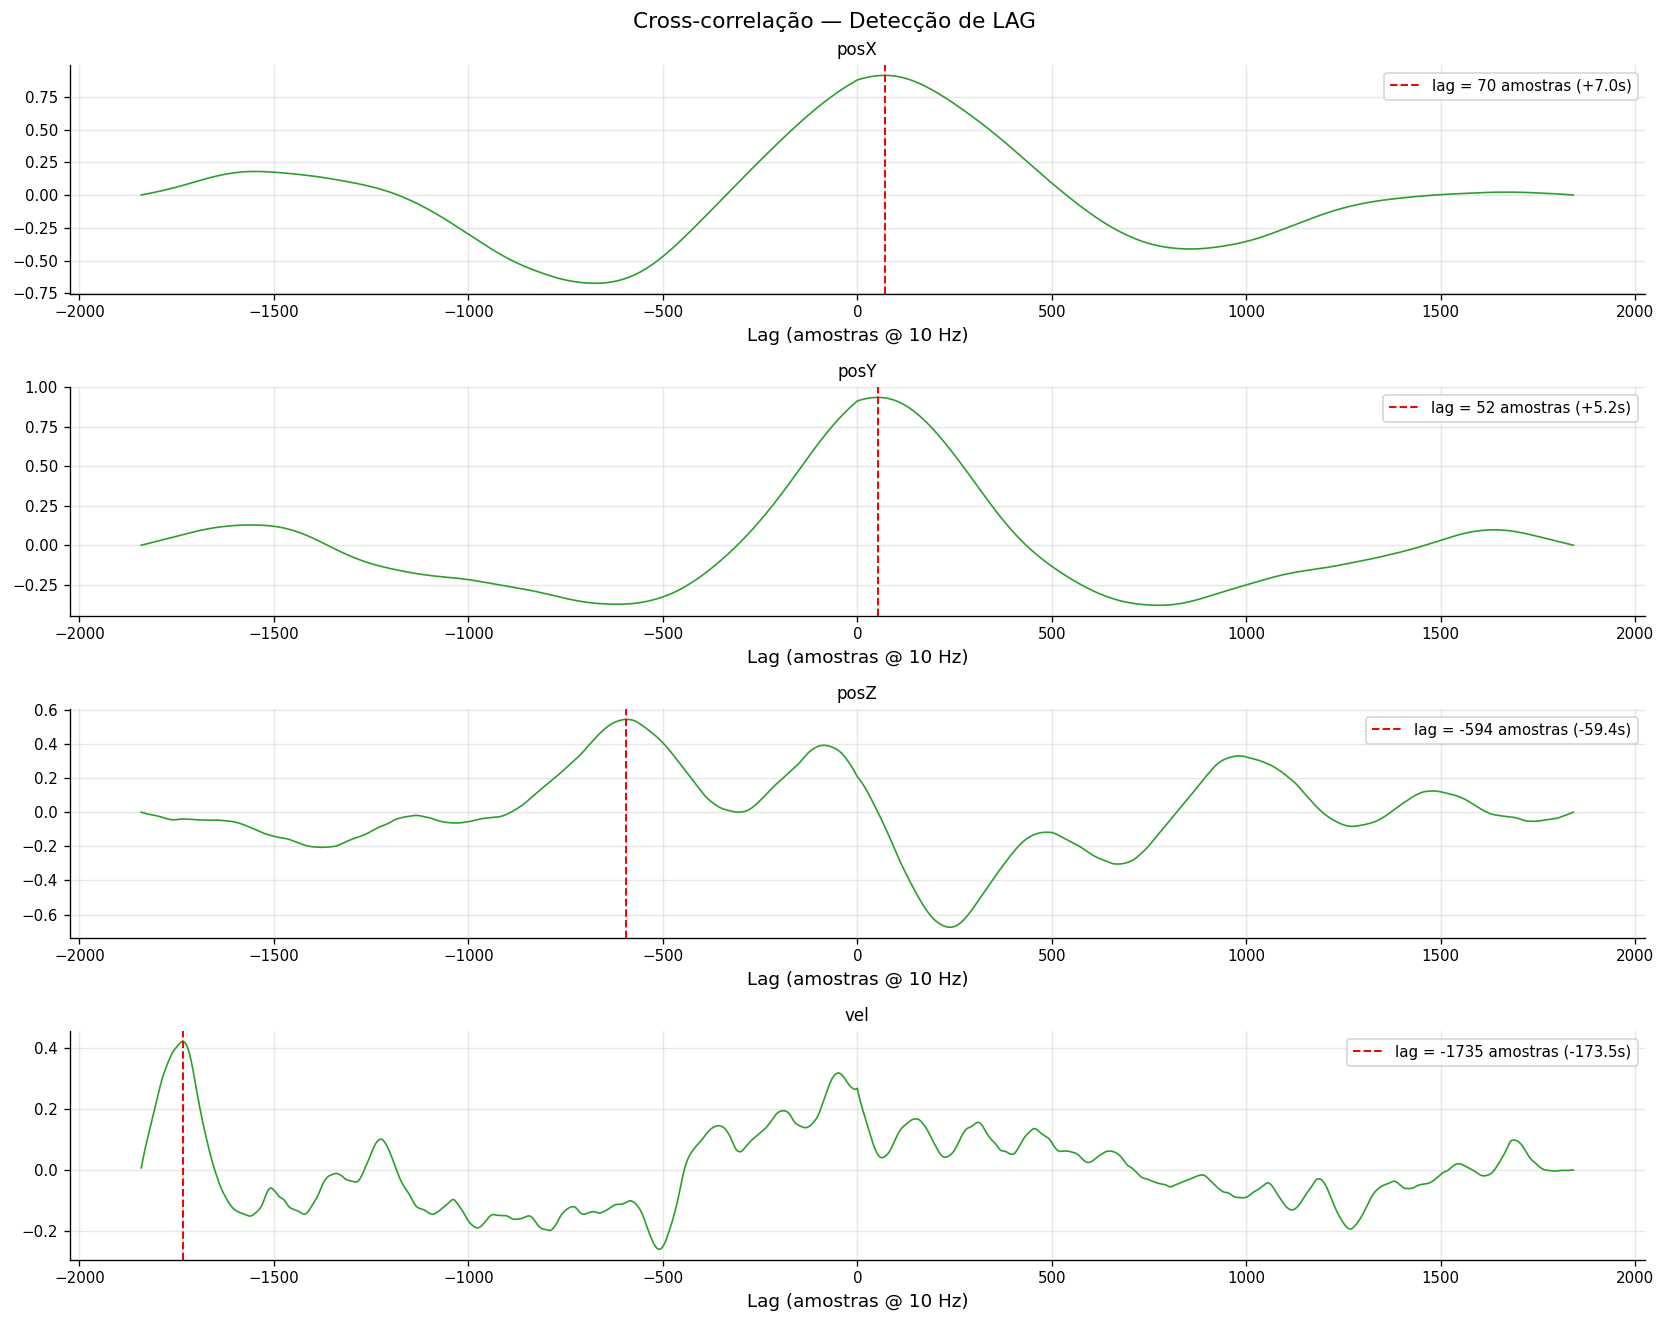


Lags detectados:
  posX      : +70 amostras = +7.0s
  posY      : +52 amostras = +5.2s
  posZ      : -594 amostras = -59.4s
  vel       : -1735 amostras = -173.5s


In [512]:
lags = {}

fig, axes = plt.subplots(len(colunas), 1, figsize=(14, 2.8 * len(colunas)))
if len(colunas) == 1:
    axes = [axes]

for ax, col in zip(axes, colunas):
    x = df[f'real_{col}'].values
    y = df[f'sim_{col}'].values

    corr      = correlate(x - x.mean(), y - y.mean(), mode='full')
    norm_denom = np.std(x) * np.std(y) * len(x)
    corr      = corr / norm_denom if norm_denom > 0 else corr

    lag_range = np.arange(-(len(x) - 1), len(x))
    lag_opt   = int(lag_range[np.argmax(corr)])
    lags[col] = lag_opt

    ax.plot(lag_range, corr, lw=1, color='#2ca02c')
    ax.axvline(lag_opt, color='red', ls='--', lw=1.2,
               label=f'lag = {lag_opt} amostras ({lag_opt * 0.1:+.1f}s)')
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=9)
    ax.set_xlabel('Lag (amostras @ 10 Hz)')

fig.suptitle('Cross-correlação — Detecção de LAG', fontsize=13)
plt.tight_layout()
plt.show()

print("\nLags detectados:")
for col, lag in lags.items():
    print(f"  {col:10s}: {lag:+d} amostras = {lag * 0.1:+.1f}s")

In [513]:
# Aplicar shift
for col, lag in lags.items():
    df[f'sim_{col}_shifted'] = df[f'sim_{col}'].shift(lag)

df = df.dropna()
print(f"Shape após shift: {df.shape}")

Shape após shift: (37, 12)


## 12. Correlação de Pearson global

In [514]:
resultados_pearson = {}

print(f"{'Coluna':<12} {'r (sem lag)':>12} {'p-value':>12} {'r (com lag)':>12} {'p-value':>12}")
print("-" * 65)

for col in colunas:
    x  = df[f'real_{col}'].values
    y  = df[f'sim_{col}'].values
    ys = df[f'sim_{col}_shifted'].values

    r_raw,   p_raw   = pearsonr(x, y)
    r_shift, p_shift = pearsonr(x, ys)

    resultados_pearson[col] = dict(r_raw=r_raw, p_raw=p_raw, r_shift=r_shift, p_shift=p_shift)
    print(f"{col:<12} {r_raw:>12.4f} {p_raw:>12.2e} {r_shift:>12.4f} {p_shift:>12.2e}")

Coluna        r (sem lag)      p-value  r (com lag)      p-value
-----------------------------------------------------------------
posX               0.9997     2.22e-57       0.9754     1.38e-24
posY              -0.2085     2.16e-01       0.4821     2.52e-03
posZ               0.8792     8.13e-13      -0.8928     1.12e-13
vel                0.8254     3.26e-10      -0.9660     3.82e-22


## 13. Pearson com Janela Deslizante

len(df) = 37
janela_pts = 12

Processando: posX
Amostras válidas: 37
posX -> len(r_valid) = 26

Processando: posY
Amostras válidas: 37
posY -> len(r_valid) = 26

Processando: posZ
Amostras válidas: 37
posZ -> len(r_valid) = 26

Processando: vel
Amostras válidas: 37
vel -> len(r_valid) = 26


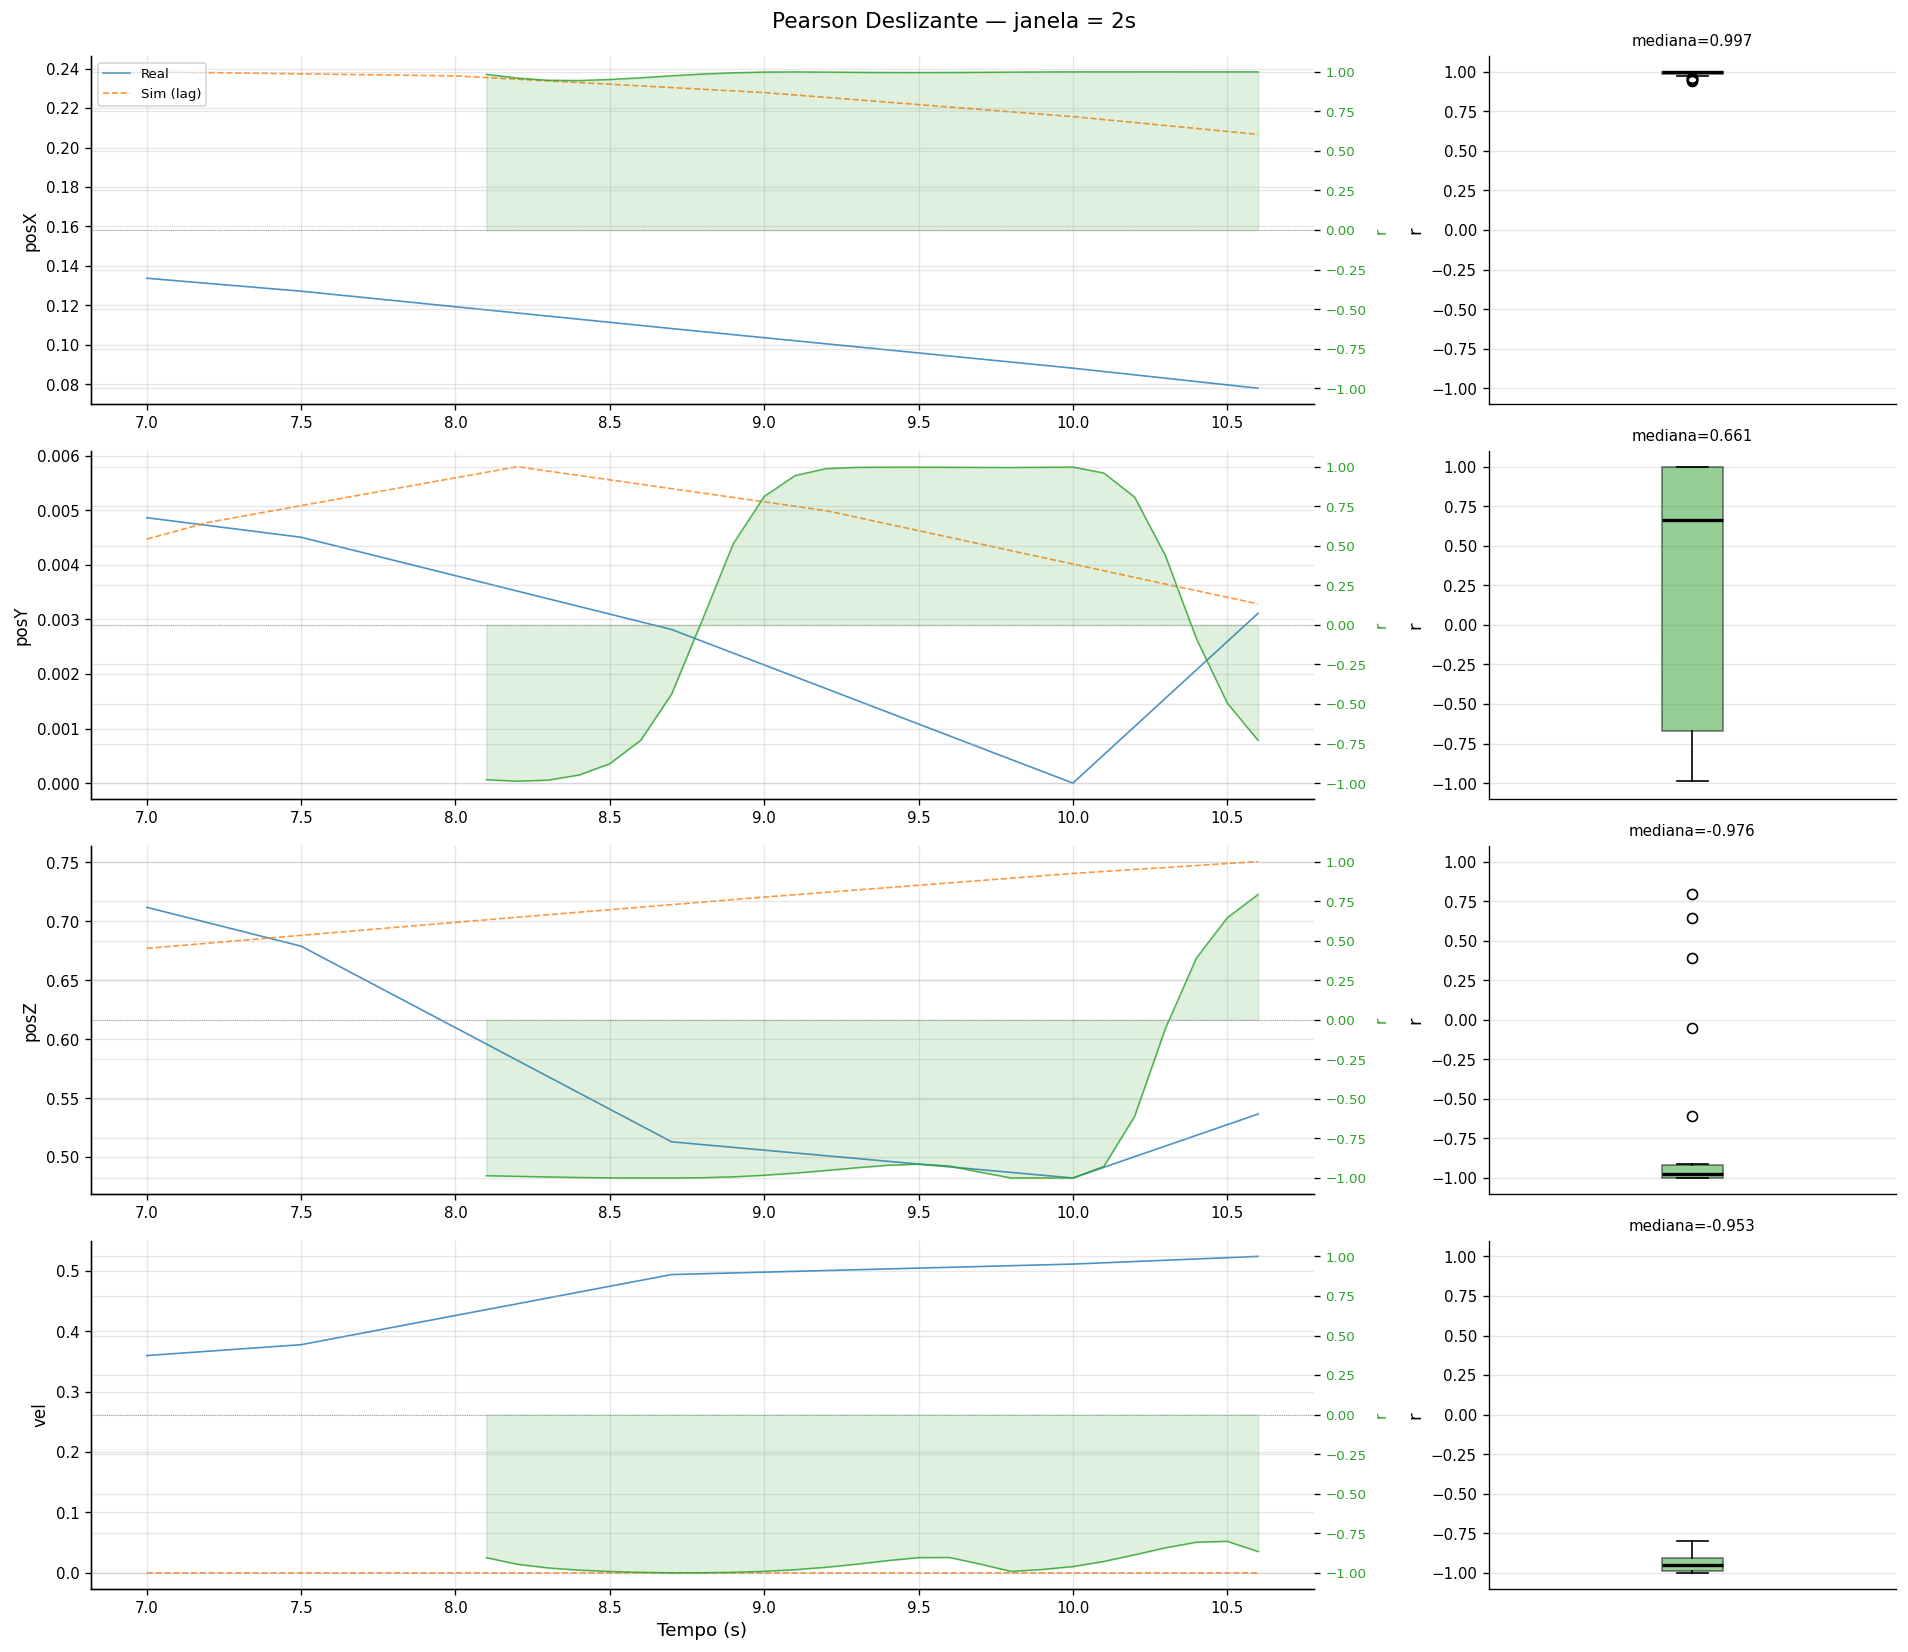

In [515]:
def pearson_sliding_window(x, y, janela=50):
    """
    Pearson deslizante vetorizado.
    Retorna NaN se a janela for maior que o sinal.
    """

    n = len(x)

    # proteção contra janela maior que o sinal
    if n < janela:
        print(f"⚠ janela={janela} maior que n={n}")
        return np.full(n, np.nan)

    r = np.full(n, np.nan)

    shape = (n - janela + 1, janela)

    strides = (x.strides[0], x.strides[0])

    X = np.lib.stride_tricks.as_strided(
        x,
        shape=shape,
        strides=strides
    )

    Y = np.lib.stride_tricks.as_strided(
        y,
        shape=shape,
        strides=strides
    )

    Xm = X - X.mean(axis=1, keepdims=True)
    Ym = Y - Y.mean(axis=1, keepdims=True)

    num = (Xm * Ym).sum(axis=1)

    denom = np.sqrt(
        (Xm**2).sum(axis=1) *
        (Ym**2).sum(axis=1)
    )

    with np.errstate(invalid='ignore'):
        r[janela - 1:] = np.where(
            denom > 1e-10,
            num / denom,
            np.nan
        )

    return r


# =====================================================
# CONFIGURAÇÕES
# =====================================================

JANELA_S = 2
FREQ_HZ = 10

janela_pts = min(JANELA_S * FREQ_HZ, max(5, len(df)//3))

print("len(df) =", len(df))
print("janela_pts =", janela_pts)

t = df.index.total_seconds().values


# =====================================================
# FIGURA
# =====================================================

fig, axes = plt.subplots(
    len(colunas),
    2,
    figsize=(16, 3.5 * len(colunas)),
    gridspec_kw={'width_ratios': [3, 1]}
)

if len(colunas) == 1:
    axes = [axes]


# =====================================================
# LOOP
# =====================================================

for i, col in enumerate(colunas):

    print(f"\nProcessando: {col}")

    x = df[f'real_{col}'].values
    ys = df[f'sim_{col}_shifted'].values

    # remover NaNs
    mask = ~np.isnan(x) & ~np.isnan(ys)

    x = x[mask]
    ys = ys[mask]
    t_valid = t[mask]

    print(f"Amostras válidas: {len(x)}")

    # Pearson deslizante
    r_slide = pearson_sliding_window(
        x,
        ys,
        janela=janela_pts
    )

    ax_ts = axes[i][0]
    ax_box = axes[i][1]

    # =================================================
    # SINAIS
    # =================================================

    ax_ts.plot(
        t_valid,
        x,
        label='Real',
        color='#1f77b4',
        lw=1.0,
        alpha=0.8
    )

    ax_ts.plot(
        t_valid,
        ys,
        label='Sim (lag)',
        color='#ff7f0e',
        lw=1.0,
        alpha=0.8,
        ls='--'
    )

    # =================================================
    # PEARSON
    # =================================================

    ax2 = ax_ts.twinx()

    ax2.fill_between(
        t_valid,
        r_slide,
        alpha=0.15,
        color='#2ca02c',
        where=~np.isnan(r_slide)
    )

    ax2.plot(
        t_valid,
        r_slide,
        color='#2ca02c',
        lw=0.9,
        alpha=0.8
    )

    ax2.set_ylim(-1.1, 1.1)

    ax2.set_ylabel(
        'r',
        color='#2ca02c',
        fontsize=9
    )

    ax2.tick_params(
        axis='y',
        labelcolor='#2ca02c',
        labelsize=8
    )

    ax2.axhline(
        0,
        color='gray',
        lw=0.5,
        ls=':'
    )

    # =================================================
    # AJUSTES
    # =================================================

    ax_ts.set_ylabel(col, fontsize=10)

    if col == 'throttle':
        ax_ts.set_ylim(-0.05, 1.05)

    if i == 0:
        ax_ts.legend(loc='upper left', fontsize=8)

    if i == len(colunas) - 1:
        ax_ts.set_xlabel('Tempo (s)')

    # =================================================
    # BOXPLOT
    # =================================================

    r_valid = r_slide[~np.isnan(r_slide)]
    print(f"{col} -> len(r_valid) = {len(r_valid)}")

    if len(r_valid) > 0:

        ax_box.boxplot(
            r_valid,
            vert=True,
            patch_artist=True,
            boxprops=dict(
                facecolor='#2ca02c',
                alpha=0.5
            ),
            medianprops=dict(
                color='black',
                lw=2
            )
        )

        mediana = np.median(r_valid)

    else:

        ax_box.text(
            0.5,
            0.5,
            'Sem dados',
            ha='center',
            va='center'
        )

        mediana = np.nan

    ax_box.set_ylim(-1.1, 1.1)

    ax_box.set_ylabel('r')

    ax_box.set_xticks([])

    ax_box.set_title(
        f'mediana={mediana:.3f}'
        if not np.isnan(mediana)
        else 'mediana=NaN',
        fontsize=9
    )


# =====================================================
# FINALIZAÇÃO
# =====================================================

fig.suptitle(
    f'Pearson Deslizante — janela = {JANELA_S}s',
    fontsize=13
)

plt.tight_layout()

plt.show()



## 14. Heatmap de Pearson por variável × tempo

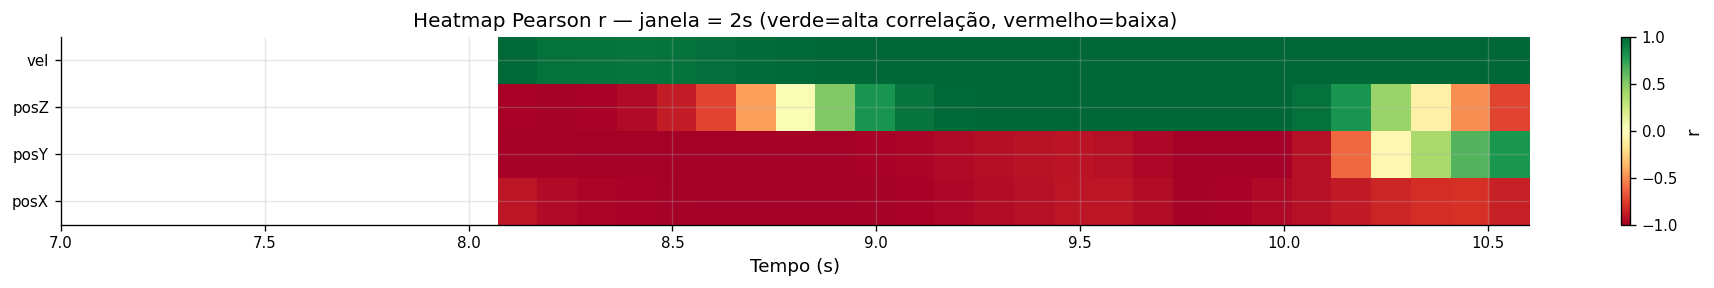

In [516]:
matriz_r = np.vstack([
    pearson_sliding_window(
        df[f'real_{col}'].values,
        df[f'sim_{col}_shifted'].values,
        janela=janela_pts
    )
    for col in colunas
])

fig, ax = plt.subplots(figsize=(16, 2.5))
im = ax.imshow(
    matriz_r, aspect='auto', cmap='RdYlGn', vmin=-1, vmax=1,
    extent=[t[0], t[-1], -0.5, len(colunas) - 0.5]
)
ax.set_yticks(range(len(colunas)))
ax.set_yticklabels(colunas)
ax.set_xlabel('Tempo (s)')
ax.set_title(f'Heatmap Pearson r — janela = {JANELA_S}s (verde=alta correlação, vermelho=baixa)')
plt.colorbar(im, ax=ax, label='r')
plt.tight_layout()
plt.show()

In [517]:
# =====================================================
# ERRO FÍSICO MÉDIO (MAE)
# =====================================================

print("\nERROS FÍSICOS MÉDIOS (Pós-alinhamento):")

for col in colunas:

    # sinais alinhados
    x_real = real[col].values[:len(df)]

    x_sim = simulado[col].shift(
        lags[col]
    ).values[:len(df)]

    # erro absoluto
    erro_abs = np.abs(x_real - x_sim)

    # remover NaNs
    erro_abs = erro_abs[~np.isnan(erro_abs)]

    # unidade
    if "pos" in col:
        unit = "m"
    elif col == "vel":
        unit = "m/s"
    else:
        unit = "%"

    # proteção
    if len(erro_abs) > 0:

        mae = np.mean(erro_abs)

        print(
            f"  {col:10s}: "
            f"{mae:.3f} {unit}"
        )

    else:

        print(
            f"  {col:10s}: "
            f"Sem dados válidos"
        )


ERROS FÍSICOS MÉDIOS (Pós-alinhamento):
  posX      : Sem dados válidos
  posY      : Sem dados válidos
  posZ      : 7.719 m
  vel       : 4.417 m/s


In [518]:
dist_error = np.sqrt((df['real_posX'] - df['sim_posX_shifted'])**2 + 
                     (df['real_posY'] - df['sim_posY_shifted'])**2)
print(f"Erro Médio de Trajetória: {dist_error.mean():.2f} metros")

Erro Médio de Trajetória: 0.12 metros


In [519]:
# =====================================================
# AJUSTE DE THROTTLE
# =====================================================

if (
    'real_throttle' in df.columns and
    'sim_throttle_shifted' in df.columns
):

    def ajustar_throttle(df, gamma=1.0):
        return np.power(
            df['sim_throttle_shifted'],
            gamma
        )

    gamma_test = 1.2

    df['sim_throttle_corrected'] = ajustar_throttle(
        df,
        gamma=gamma_test
    )

    from sklearn.metrics import mean_absolute_error

    erro_antes = mean_absolute_error(
        df['real_throttle'],
        df['sim_throttle_shifted']
    )

    erro_depois = mean_absolute_error(
        df['real_throttle'],
        df['sim_throttle_corrected']
    )

    print(
        f"Erro Throttle Original: "
        f"{erro_antes:.2%}"
    )

    print(
        f"Erro Throttle Corrigido "
        f"(gamma={gamma_test}): "
        f"{erro_depois:.2%}"
    )

else:

    print(
        "⚠ Dados de throttle não disponíveis "
        "para comparação."
    )

⚠ Dados de throttle não disponíveis para comparação.


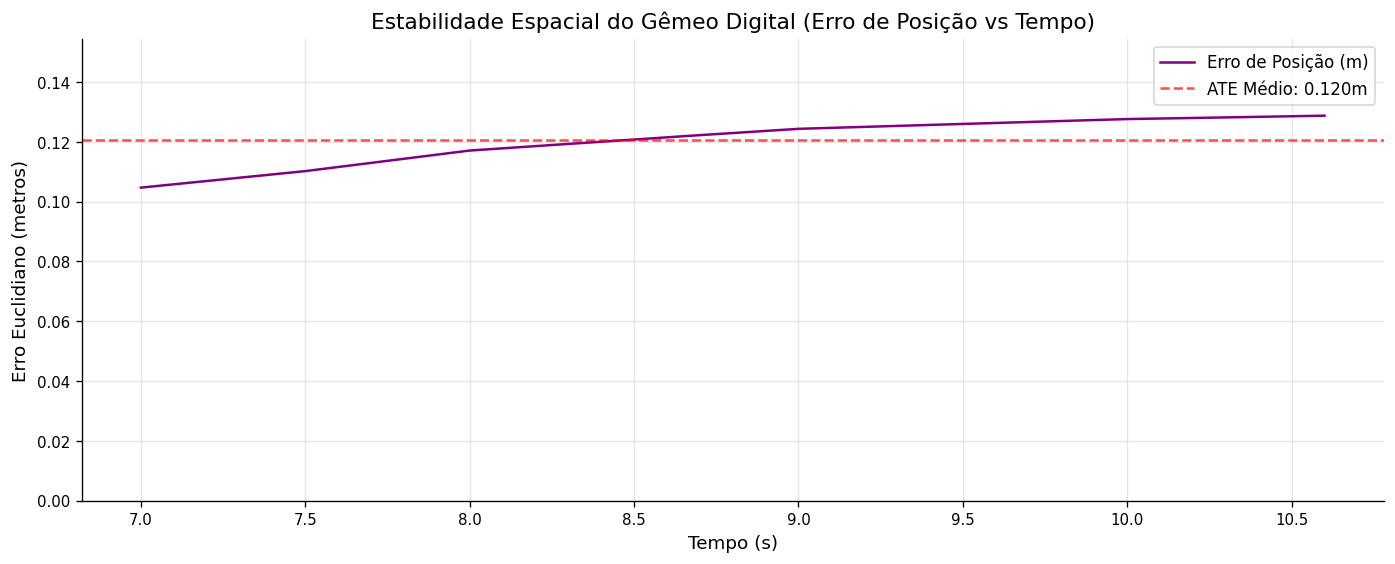

In [520]:
# Cálculo do erro euclidiano ponto a ponto (distância real no plano XY)
df['erro_distancia'] = np.sqrt(
    (df['real_posX'] - df['sim_posX_shifted'])**2 + 
    (df['real_posY'] - df['sim_posY_shifted'])**2
)

plt.figure(figsize=(14, 5))
plt.plot(df.index.total_seconds(), df['erro_distancia'], color='purple', lw=1.5, label='Erro de Posição (m)')

# Linha de média
ate_medio = df['erro_distancia'].mean()
plt.axhline(ate_medio, color='red', linestyle='--', alpha=0.7, label=f'ATE Médio: {ate_medio:.3f}m')

plt.title('Estabilidade Espacial do Gêmeo Digital (Erro de Posição vs Tempo)', fontsize=13)
plt.xlabel('Tempo (s)')
plt.ylabel('Erro Euclidiano (metros)')
plt.ylim(0, max(df['erro_distancia']) * 1.2) # Foco no zero
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [521]:
if (
    'real_throttle' in df.columns and
    'sim_throttle_shifted' in df.columns
):

    print(
        f"Máximo Real: "
        f"{df['real_throttle'].max()}"
    )

    print(
        f"Máximo Simulado: "
        f"{df['sim_throttle_shifted'].max()}"
    )

else:

    print(
        "⚠ Colunas de throttle não existem no DataFrame."
    )

    print("\nColunas disponíveis:")
    print(df.columns.tolist())

⚠ Colunas de throttle não existem no DataFrame.

Colunas disponíveis:
['real_posX', 'real_posY', 'real_posZ', 'real_vel', 'sim_posX', 'sim_posY', 'sim_posZ', 'sim_vel', 'sim_posX_shifted', 'sim_posY_shifted', 'sim_posZ_shifted', 'sim_vel_shifted', 'erro_distancia']


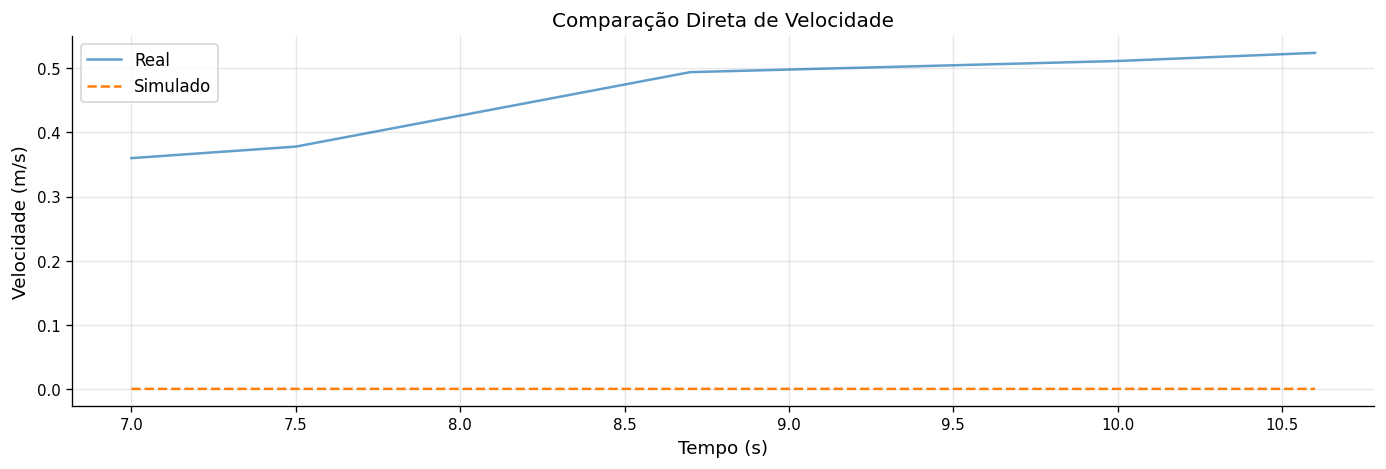

In [522]:
plt.figure(figsize=(14, 4))

plt.plot(
    df.index.total_seconds(),
    df['real_vel'],
    label='Real',
    alpha=0.7
)

plt.plot(
    df.index.total_seconds(),
    df['sim_vel_shifted'],
    label='Simulado',
    linestyle='--'
)

plt.title('Comparação Direta de Velocidade')

plt.xlabel('Tempo (s)')

plt.ylabel('Velocidade (m/s)')

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

In [523]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

scaler = MinMaxScaler()

# =====================================================
# NORMALIZAÇÃO DA VELOCIDADE
# =====================================================

df['real_vel_norm'] = scaler.fit_transform(
    df[['real_vel']]
)

df['sim_vel_norm'] = scaler.fit_transform(
    df[['sim_vel_shifted']]
)

# =====================================================
# ERRO
# =====================================================

erro_norm = mean_absolute_error(
    df['real_vel_norm'],
    df['sim_vel_norm']
)

print(
    f"Erro de Velocidade Normalizada: "
    f"{erro_norm:.2%}"
)

Erro de Velocidade Normalizada: 67.95%


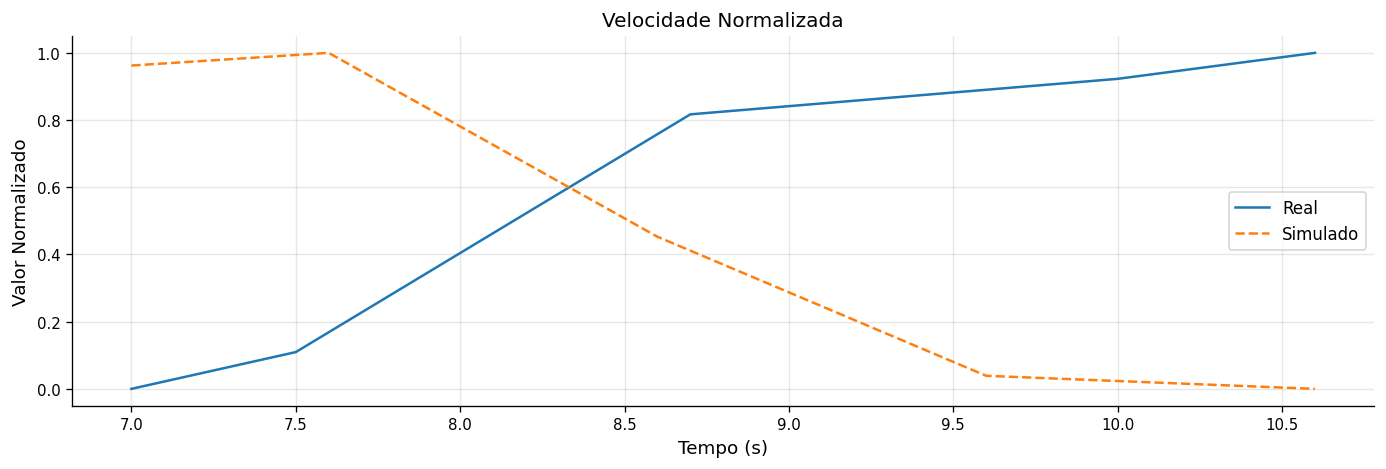

In [524]:
plt.figure(figsize=(14,4))

plt.plot(
    df.index.total_seconds(),
    df['real_vel_norm'],
    label='Real'
)

plt.plot(
    df.index.total_seconds(),
    df['sim_vel_norm'],
    label='Simulado',
    linestyle='--'
)

plt.title('Velocidade Normalizada')

plt.xlabel('Tempo (s)')

plt.ylabel('Valor Normalizado')

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

In [525]:
from scipy.stats import linregress
import numpy as np

# =====================================================
# REGRESSÃO LINEAR
# Real = slope * Simulado + intercept
# =====================================================

slope, intercept, r_value, p_value, std_err = linregress(
    df['sim_vel_shifted'],
    df['real_vel']
)

# =====================================================
# MAPEAMENTO
# =====================================================

df['sim_vel_mapped'] = (
    df['sim_vel_shifted'] * slope
    + intercept
)

# =====================================================
# ERRO FINAL
# =====================================================

erro_final = np.abs(
    df['real_vel'] - df['sim_vel_mapped']
).mean()

print(
    f"Novo Erro de Velocidade: "
    f"{erro_final:.4f} m/s"
)

print(
    f"R² (Correlação): "
    f"{r_value**2:.4f}"
)

print(
    f"Slope: {slope:.4f}"
)

print(
    f"Intercept: {intercept:.4f}"
)

Novo Erro de Velocidade: 0.0122 m/s
R² (Correlação): 0.9331
Slope: -13352.1242
Intercept: 0.5255


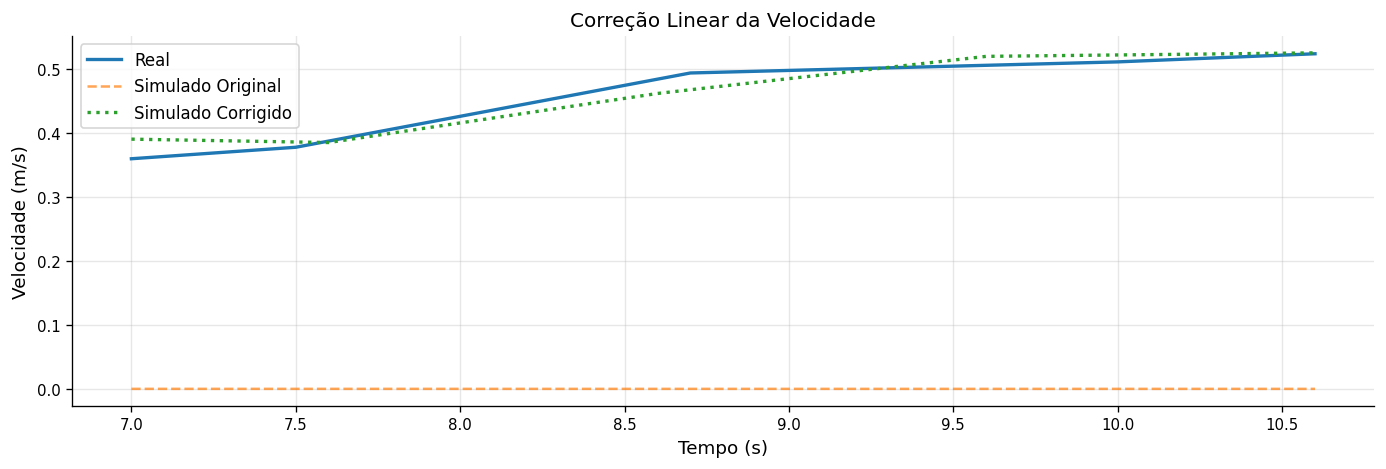

In [526]:
plt.figure(figsize=(14,4))

plt.plot(
    df.index.total_seconds(),
    df['real_vel'],
    label='Real',
    linewidth=2
)

plt.plot(
    df.index.total_seconds(),
    df['sim_vel_shifted'],
    label='Simulado Original',
    linestyle='--',
    alpha=0.7
)

plt.plot(
    df.index.total_seconds(),
    df['sim_vel_mapped'],
    label='Simulado Corrigido',
    linestyle=':',
    linewidth=2
)

plt.title('Correção Linear da Velocidade')

plt.xlabel('Tempo (s)')

plt.ylabel('Velocidade (m/s)')

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

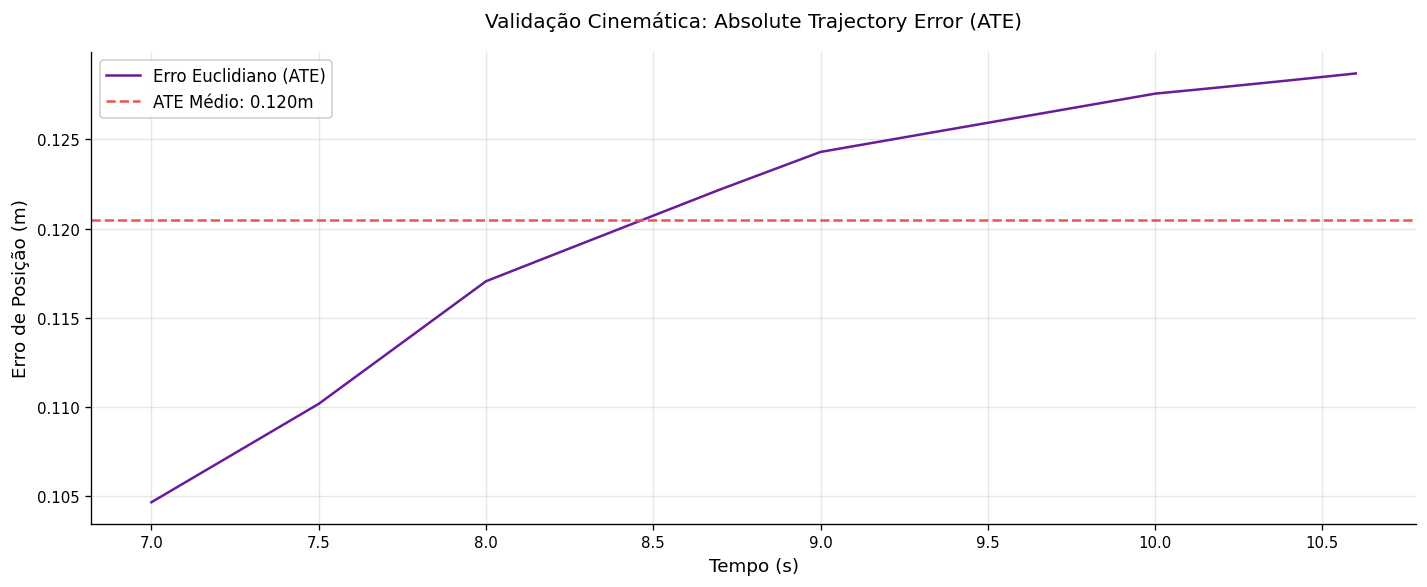

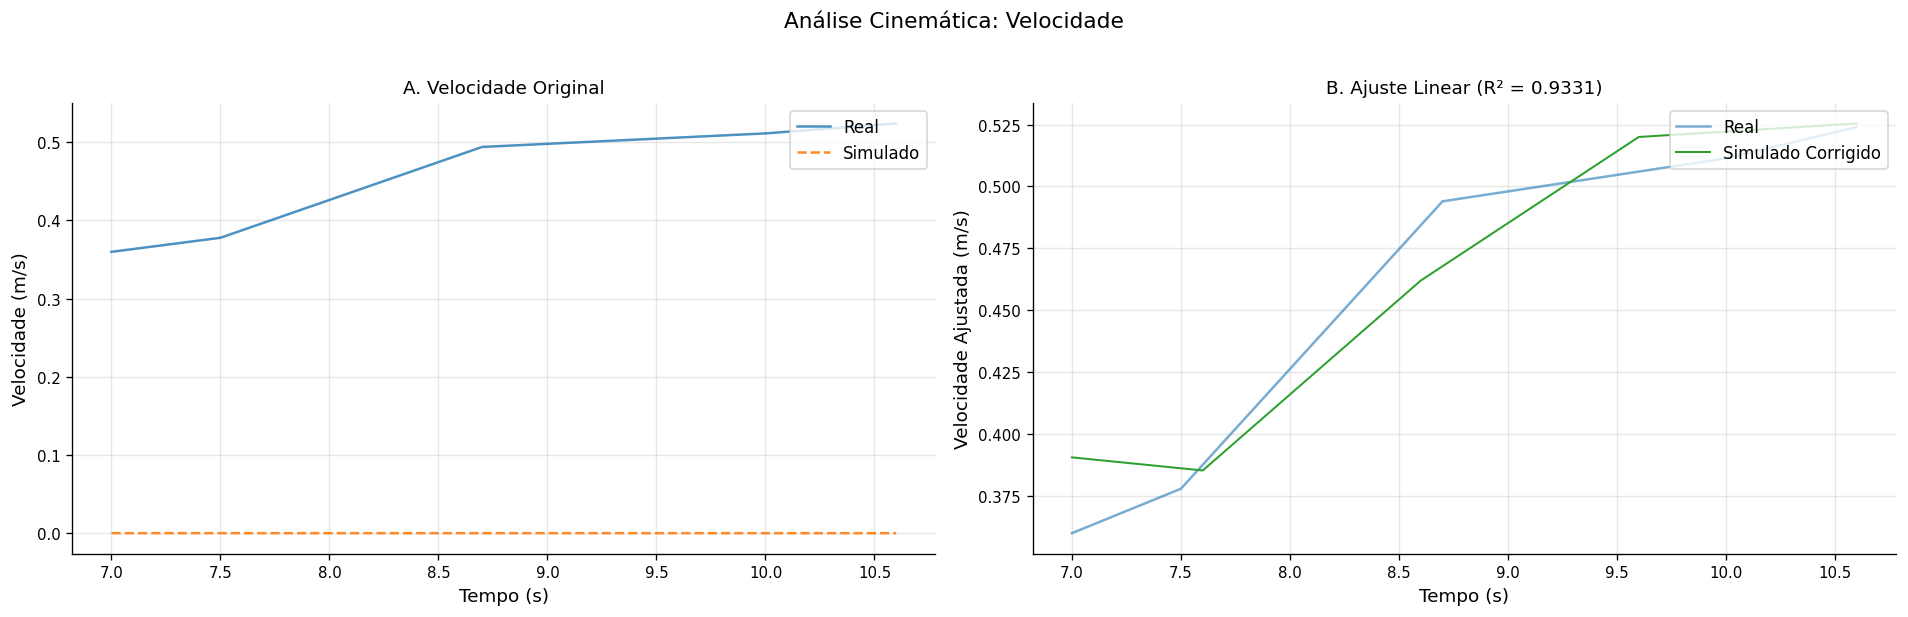

In [527]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# CONFIGURAÇÃO VISUAL
# =====================================================

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


# =====================================================
# 1. ATE
# =====================================================

def plot_ate(df):

    t = df.index.total_seconds()

    ate_medio = df['erro_distancia'].mean()

    plt.figure(figsize=(12, 5))

    plt.plot(
        t,
        df['erro_distancia'],
        color='#6a1b9a',
        lw=1.5,
        label='Erro Euclidiano (ATE)'
    )

    plt.axhline(
        ate_medio,
        color='#ef5350',
        linestyle='--',
        lw=1.5,
        label=f'ATE Médio: {ate_medio:.3f}m'
    )

    plt.title(
        'Validação Cinemática: Absolute Trajectory Error (ATE)',
        pad=15
    )

    plt.xlabel('Tempo (s)')

    plt.ylabel('Erro de Posição (m)')

    plt.legend(
        frameon=True,
        facecolor='white',
        framealpha=0.9
    )

    plt.tight_layout()

    plt.show()


# =====================================================
# 2. COMPARAÇÃO DE VELOCIDADE
# =====================================================

def plot_velocity_comparison(df, r_squared):

    t = df.index.total_seconds()

    fig, (ax1, ax2) = plt.subplots(
        1,
        2,
        figsize=(16, 5),
        sharey=False
    )

    # -------------------------------------------------
    # A. SINAIS ORIGINAIS
    # -------------------------------------------------

    ax1.plot(
        t,
        df['real_vel'],
        color='#1f77b4',
        alpha=0.8,
        label='Real'
    )

    ax1.plot(
        t,
        df['sim_vel_shifted'],
        color='#ff7f0e',
        ls='--',
        alpha=0.9,
        label='Simulado'
    )

    ax1.set_title(
        'A. Velocidade Original',
        fontsize=11
    )

    ax1.set_ylabel('Velocidade (m/s)')

    ax1.set_xlabel('Tempo (s)')

    ax1.legend(loc='upper right')

    # -------------------------------------------------
    # B. SINAL CORRIGIDO
    # -------------------------------------------------

    ax2.plot(
        t,
        df['real_vel'],
        color='#1f77b4',
        alpha=0.6,
        label='Real'
    )

    ax2.plot(
        t,
        df['sim_vel_mapped'],
        color='#2ca02c',
        ls='-',
        lw=1.2,
        label='Simulado Corrigido'
    )

    ax2.set_title(
        f'B. Ajuste Linear (R² = {r_squared:.4f})',
        fontsize=11
    )

    ax2.set_ylabel('Velocidade Ajustada (m/s)')

    ax2.set_xlabel('Tempo (s)')

    ax2.legend(loc='upper right')

    plt.suptitle(
        'Análise Cinemática: Velocidade',
        fontsize=13,
        y=1.02
    )

    plt.tight_layout()

    plt.show()


# =====================================================
# EXECUÇÃO
# =====================================================

plot_ate(df)

plot_velocity_comparison(
    df,
    r_value**2
)

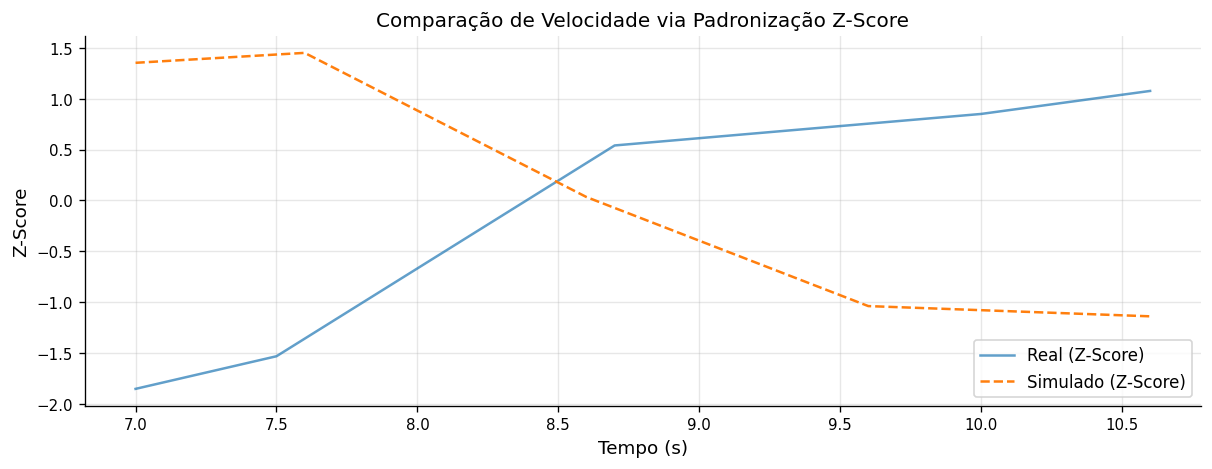

In [528]:
# =====================================================
# PADRONIZAÇÃO Z-SCORE DA VELOCIDADE
# =====================================================

df['real_vel_z'] = (
    df['real_vel'] - df['real_vel'].mean()
) / df['real_vel'].std()

df['sim_vel_z'] = (
    df['sim_vel_shifted'] - df['sim_vel_shifted'].mean()
) / df['sim_vel_shifted'].std()

# =====================================================
# GRÁFICO
# =====================================================

plt.figure(figsize=(12, 4))

plt.plot(
    df.index.total_seconds(),
    df['real_vel_z'],
    label='Real (Z-Score)',
    alpha=0.7
)

plt.plot(
    df.index.total_seconds(),
    df['sim_vel_z'],
    label='Simulado (Z-Score)',
    linestyle='--'
)

plt.title(
    'Comparação de Velocidade via Padronização Z-Score'
)

plt.xlabel('Tempo (s)')

plt.ylabel('Z-Score')

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

In [529]:
from scipy.stats import linregress

# =====================================================
# SUAVIZAÇÃO DA VELOCIDADE DO SIMULADOR
# =====================================================

df['sim_vel_smooth'] = (
    df['sim_vel_shifted']
    .rolling(window=10)
    .mean()
)

# =====================================================
# REMOVE NaN GERADOS PELA SUAVIZAÇÃO
# =====================================================

mask = ~df['sim_vel_smooth'].isna()

# =====================================================
# REGRESSÃO LINEAR
# =====================================================

slope, intercept, r_val, p_val, std_err = linregress(
    df.loc[mask, 'sim_vel_smooth'],
    df.loc[mask, 'real_vel']
)

print(
    f"Novo R² após suavização: "
    f"{r_val**2:.4f}"
)

print(f"Slope: {slope:.4f}")

print(f"Intercept: {intercept:.4f}")

Novo R² após suavização: 0.8449
Slope: -7993.9041
Intercept: 0.5267


## 15. Resumo final

In [530]:
print("=" * 60)
print("RESUMO — REAL × SIMULADO BeamNG Digital Twin")
print("=" * 60)
print(f"{'Variável':<10} {'r_global':>9} {'r_mediana':>10} {'lag (s)':>9}")
print("-" * 45)

for col in colunas:
    r_global = resultados_pearson[col]['r_shift']
    r_slide  = pearson_sliding_window(
        df[f'real_{col}'].values,
        df[f'sim_{col}_shifted'].values,
        janela=janela_pts
    )
    r_med = np.nanmedian(r_slide)
    lag_s = lags[col] * 0.1
    print(f"{col:<10} {r_global:>9.4f} {r_med:>10.4f} {lag_s:>+9.1f}s")

print("=" * 60)

RESUMO — REAL × SIMULADO BeamNG Digital Twin
Variável    r_global  r_mediana   lag (s)
---------------------------------------------
posX          0.9754     0.9968      +7.0s
posY          0.4821     0.6610      +5.2s
posZ         -0.8928    -0.9760     -59.4s
vel          -0.9660    -0.9529    -173.5s


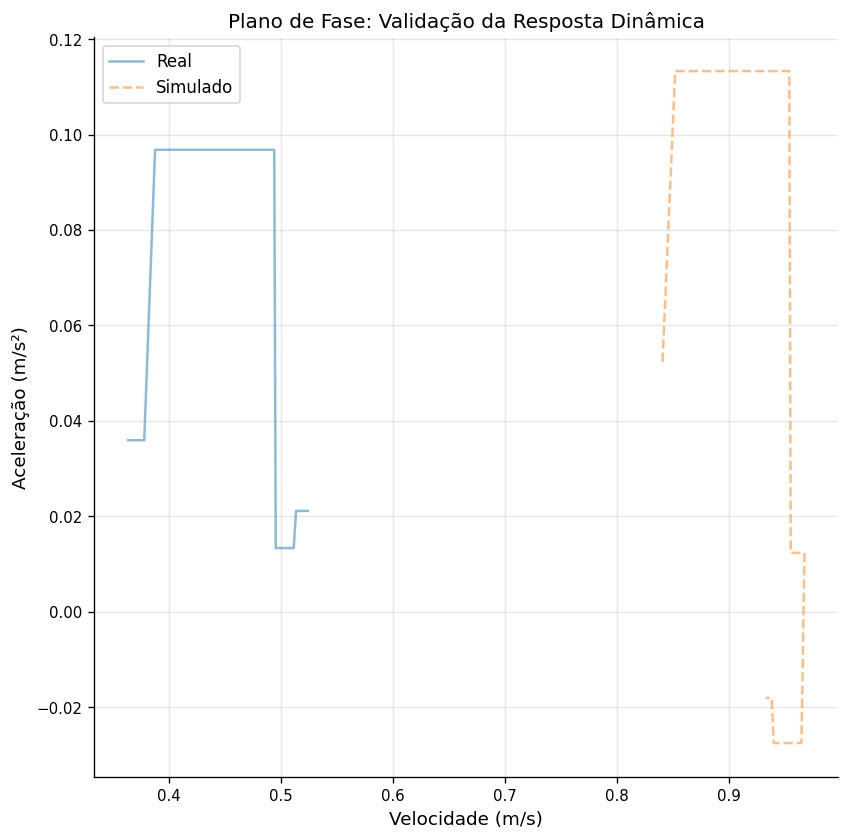

In [531]:
# Cálculo da aceleração (derivada da velocidade)
df['real_accel'] = df['real_vel'].diff() / 0.1
df['sim_accel'] = df['sim_vel'].diff() / 0.1

plt.figure(figsize=(8, 8))
plt.plot(df['real_vel'], df['real_accel'], label='Real', alpha=0.5)
plt.plot(df['sim_vel'], df['sim_accel'], label='Simulado', alpha=0.5, ls='--')
plt.xlabel('Velocidade (m/s)')
plt.ylabel('Aceleração (m/s²)')
plt.title('Plano de Fase: Validação da Resposta Dinâmica')
plt.legend()
plt.show()

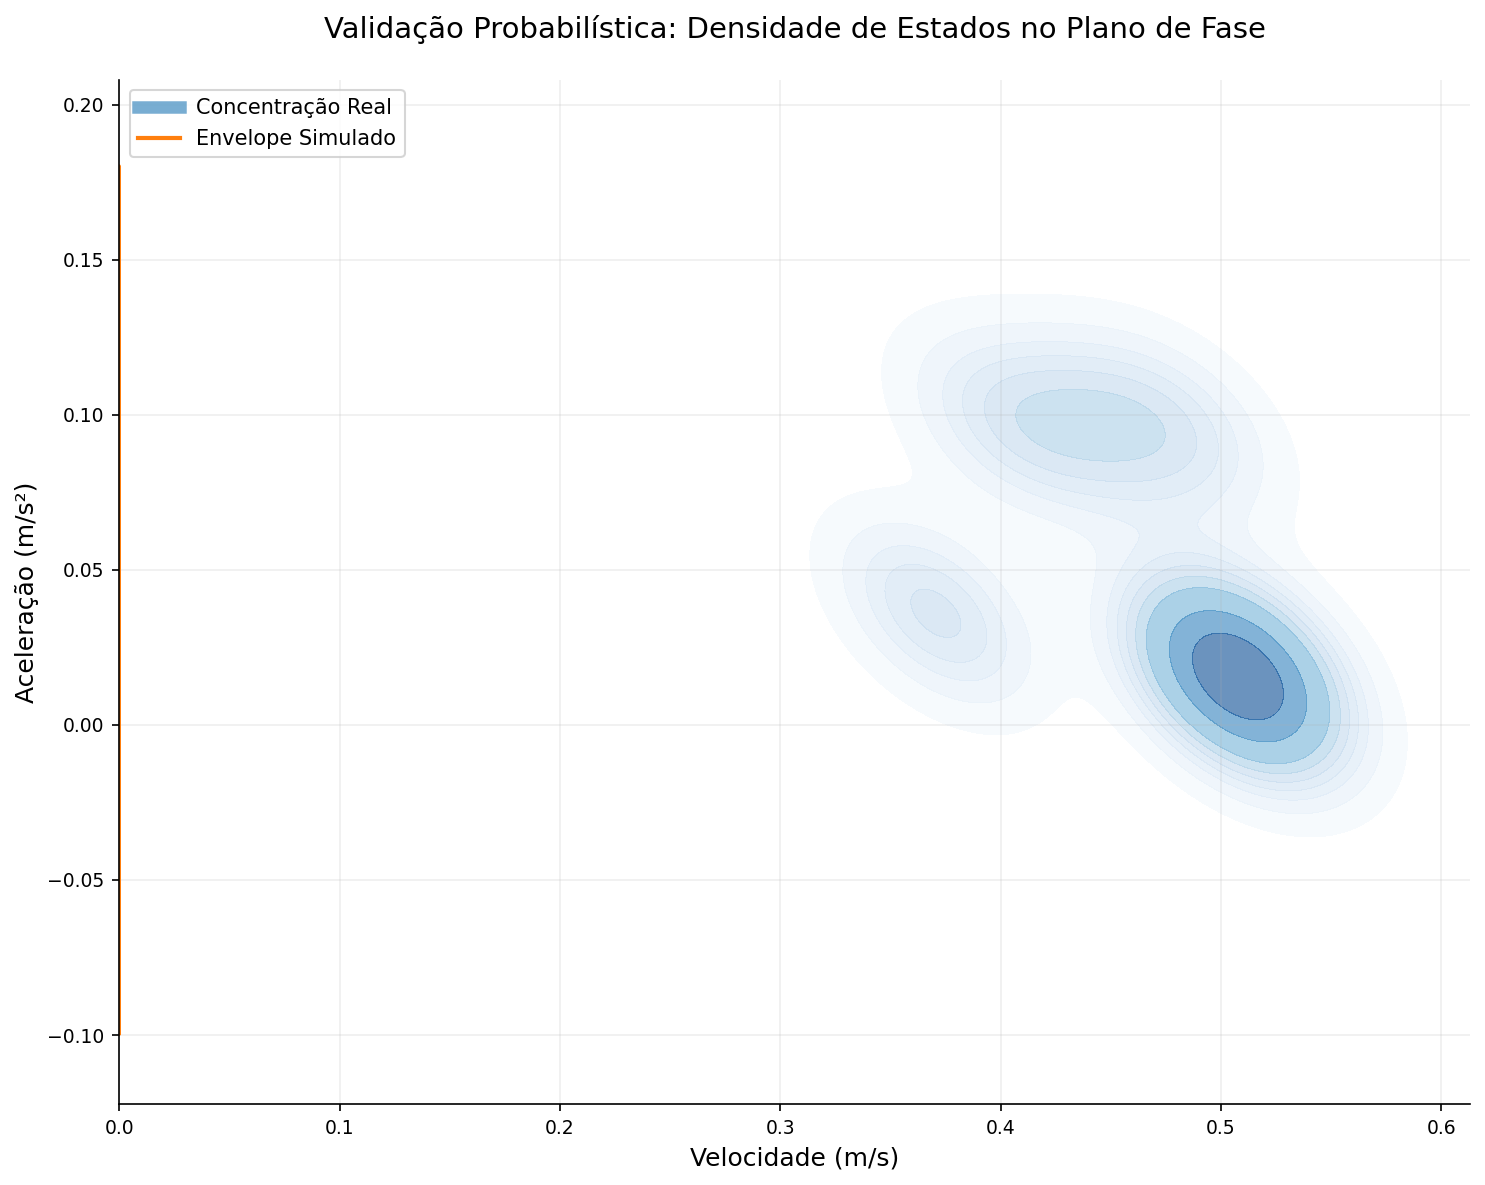

In [532]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

def plot_kde_validacao(df):
    """
    Gera o gráfico de densidade (KDE) para o Plano de Fase.
    Requer as colunas: 'real_vel', 'real_accel', 'sim_vel_shifted' e 'sim_accel'.
    """
    
    # Configurações de estilo para publicação
    plt.rcParams.update({
        'figure.dpi': 150,
        'font.size': 10,
        'axes.grid': True,
        'grid.alpha': 0.2
    })

    plt.figure(figsize=(10, 8))

    # 1. Camada de Densidade Real (Preenchida/Heatmap)
    sns.kdeplot(
        x=df['real_vel'], 
        y=df['real_accel'], 
        fill=True, 
        cmap="Blues", 
        alpha=0.6, 
        thresh=0.05, 
        label='Concentração Real'
    )

    # 2. Camada do Envelope Simulado (Apenas contornos)
    sns.kdeplot(
        x=df['sim_vel_shifted'], 
        y=df['sim_accel'], 
        fill=False, 
        color="#ff7f0e", 
        levels=5, 
        linewidths=1.5, 
        label='Envelope Simulado'
    )

    # Títulos e Eixos
    plt.title('Validação Probabilística: Densidade de Estados no Plano de Fase', pad=20, fontsize=14)
    plt.xlabel('Velocidade (m/s)', fontsize=12)
    plt.ylabel('Aceleração (m/s²)', fontsize=12)
    
    # Legenda customizada para garantir que apareça corretamente
    legend_elements = [
        Line2D([0], [0], color='#1f77b4', lw=6, alpha=0.6, label='Concentração Real'),
        Line2D([0], [0], color='#ff7f0e', lw=2, label='Envelope Simulado')
    ]
    plt.legend(handles=legend_elements, loc='upper left', frameon=True)

    plt.tight_layout()
    plt.show()

# Chamada da função
plot_kde_validacao(df)

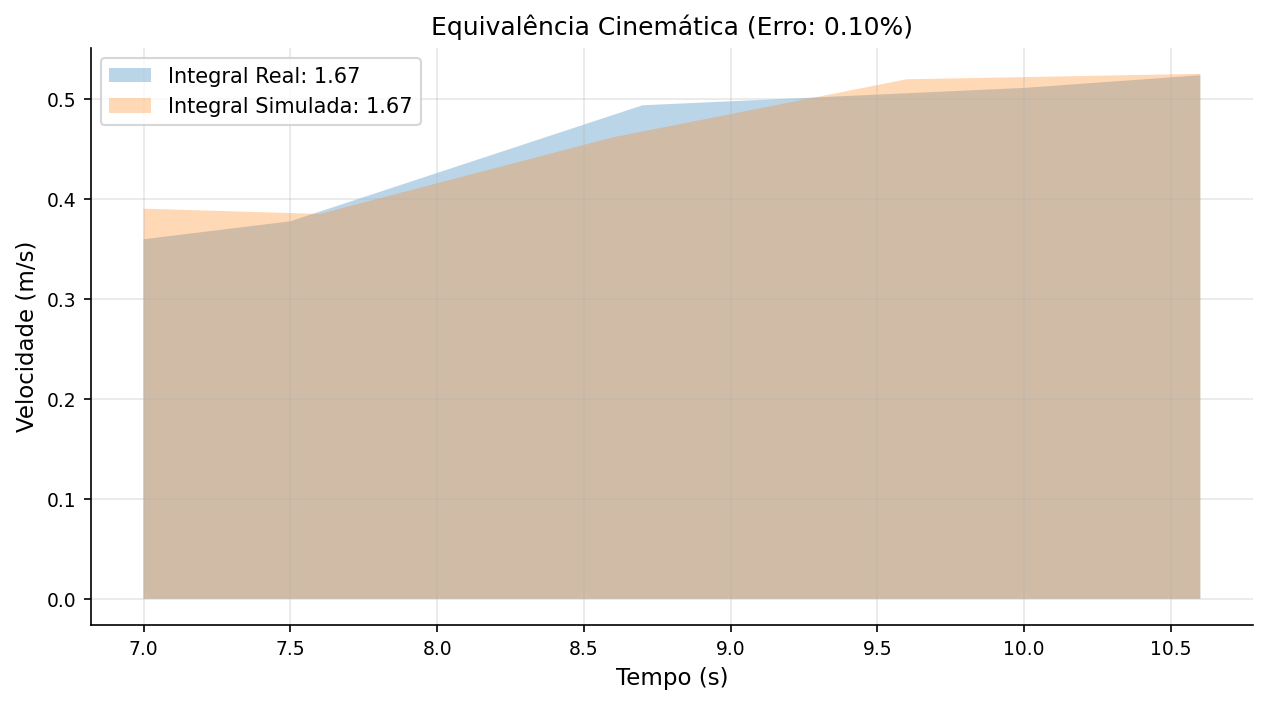

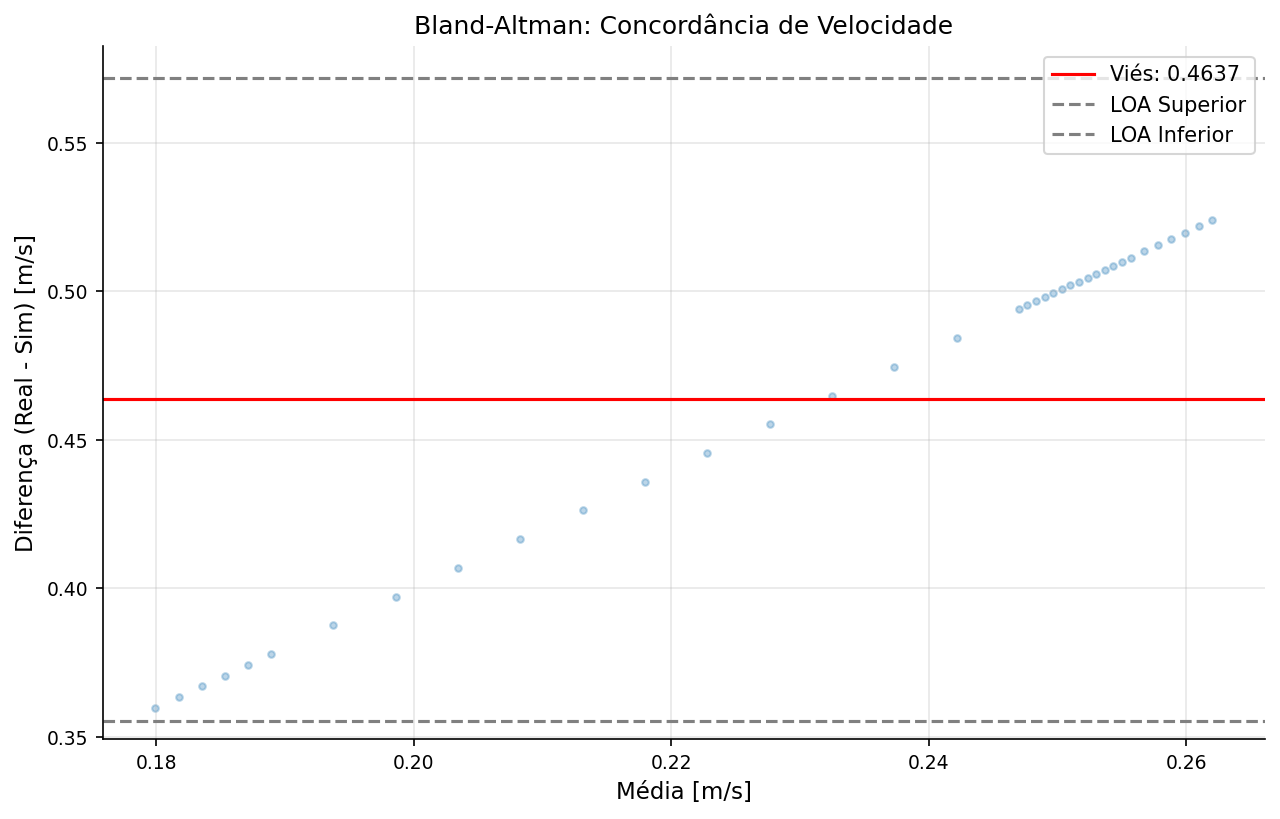

In [533]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson

# =====================================================
# 1. ANÁLISE DE INTEGRAL
# =====================================================

t = df.index.total_seconds()

integral_real = simpson(
    df['real_vel'],
    x=t
)

integral_sim = simpson(
    df['sim_vel_mapped'],
    x=t
)

erro_int = (
    abs(integral_real - integral_sim)
    / abs(integral_real)
) * 100

plt.figure(figsize=(10, 5))

plt.fill_between(
    t,
    df['real_vel'],
    alpha=0.3,
    label=f'Integral Real: {integral_real:.2f}'
)

plt.fill_between(
    t,
    df['sim_vel_mapped'],
    alpha=0.3,
    label=f'Integral Simulada: {integral_sim:.2f}'
)

plt.title(
    f'Equivalência Cinemática '
    f'(Erro: {erro_int:.2f}%)'
)

plt.xlabel('Tempo (s)')

plt.ylabel('Velocidade (m/s)')

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()


# =====================================================
# 2. BLAND-ALTMAN
# =====================================================

mean_v = (
    df['real_vel']
    + df['sim_vel_shifted']
) / 2

diff_v = (
    df['real_vel']
    - df['sim_vel_shifted']
)

md = np.mean(diff_v)

sd = np.std(diff_v)

plt.figure(figsize=(10, 6))

plt.scatter(
    mean_v,
    diff_v,
    alpha=0.3,
    s=10
)

plt.axhline(
    md,
    color='red',
    label=f'Viés: {md:.4f}'
)

plt.axhline(
    md + 1.96 * sd,
    color='gray',
    linestyle='--',
    label='LOA Superior'
)

plt.axhline(
    md - 1.96 * sd,
    color='gray',
    linestyle='--',
    label='LOA Inferior'
)

plt.title(
    'Bland-Altman: Concordância de Velocidade'
)

plt.ylabel(
    'Diferença (Real - Sim) [m/s]'
)

plt.xlabel(
    'Média [m/s]'
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()